In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
import os
warnings.filterwarnings("ignore")

In [44]:
df = pd.read_csv("../../Data/data_with_weather.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

print("=== Dataset Info ===")
print(f"Shape        : {df.shape}")
print(f"Date range   : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Missing vals :\n{df.isnull().sum()}")
print(f"\nDemand stats :\n{df['demand'].describe()}")


=== Dataset Info ===
Shape        : (28416, 13)
Date range   : 2020-03-04 03:00:00 → 2023-06-01 02:00:00
Missing vals :
datetime       0
demand         0
hour           0
day_of_week    0
is_weekend     0
event          0
temp           0
feelslike      0
precip         0
snow           0
snowdepth      0
is_snowing     0
is_raining     0
dtype: int64

Demand stats :
count     28416.000000
mean      13604.210058
std       19733.731770
min           0.000000
25%           0.000000
50%         604.000000
75%       24905.000000
max      193464.000000
Name: demand, dtype: float64


In [45]:
def engineer_features(df):
    df = df.copy()

    # -- Time features --
    df["month"]            = df["datetime"].dt.month
    df["week_of_year"]     = df["datetime"].dt.isocalendar().week.astype(int)
    df["day_of_month"]     = df["datetime"].dt.day
    df["is_morning_peak"]  = ((df["hour"] >= 7)  & (df["hour"] <= 9)).astype(int)
    df["is_evening_peak"]  = ((df["hour"] >= 16) & (df["hour"] <= 18)).astype(int)
    df["is_midday"]        = ((df["hour"] >= 11) & (df["hour"] <= 14)).astype(int)
    df["is_late_night"]    = ((df["hour"] >= 22) | (df["hour"] <= 5)).astype(int)

    # Cyclical encoding — captures that hour 23 and hour 0 are close, not far apart
    df["hour_sin"]   = np.sin(2 * np.pi * df["hour"]        / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hour"]        / 24)
    df["dow_sin"]    = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"]    = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["month_sin"]  = np.sin(2 * np.pi * df["month"]       / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df["month"]       / 12)

    # -- Weather features --
    df["feels_cold"]       = (df["feelslike"] < 32).astype(int)
    df["feels_very_cold"]  = (df["feelslike"] < 20).astype(int)
    df["heavy_snow"]       = (df["snowdepth"] > 3).astype(int)
    df["bad_weather"]      = (df["is_snowing"] | df["is_raining"]).astype(int)
    df["cold_and_snowing"] = (df["feels_cold"] & df["is_snowing"]).astype(int)
    df["temp_x_hour"]      = df["temp"] * df["hour"]   # interaction term

    # -- Lag features (past demand) --
    # Gives XGBoost temporal context, similar to how LSTM uses sequences
    for lag in [1, 2, 3, 24, 48, 168]:    # 1-3 hrs, yesterday, 2 days, 1 week ago
        df[f"demand_lag_{lag}"] = df["demand"].shift(lag)

    # -- Rolling window statistics --
    df["demand_roll_mean_3h"]  = df["demand"].shift(1).rolling(3).mean()
    df["demand_roll_mean_24h"] = df["demand"].shift(1).rolling(24).mean()
    df["demand_roll_std_24h"]  = df["demand"].shift(1).rolling(24).std()
    df["demand_roll_max_24h"]  = df["demand"].shift(1).rolling(24).max()

    # Drop rows with NaN from lags
    df = df.dropna().reset_index(drop=True)
    return df


df_feat = engineer_features(df)
print(f"\nAfter feature engineering: {df_feat.shape}")



After feature engineering: (28248, 42)


In [46]:
FEATURE_COLS = [
    "demand",
    # Raw time
    "hour", "day_of_week", "is_weekend", "month", "week_of_year", "day_of_month",
    # Peak flags
    "is_morning_peak", "is_evening_peak", "is_midday", "is_late_night",
    # Cyclical encodings
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
    # Weather
    "temp", "feelslike", "precip", "snow", "snowdepth", "is_snowing", "is_raining",
    # Weather interactions
    "feels_cold", "feels_very_cold", "heavy_snow", "bad_weather",
    "cold_and_snowing", "temp_x_hour",
    # Events
    "event",
    # Lag features
    "demand_lag_1", "demand_lag_2", "demand_lag_3",
    "demand_lag_24", "demand_lag_48", "demand_lag_168",
    # Rolling stats
    "demand_roll_mean_3h", "demand_roll_mean_24h",
    "demand_roll_std_24h", "demand_roll_max_24h",
]

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df_feat[FEATURE_COLS])
scaled_frame = pd.DataFrame(scaled_data, columns=scaler.get_feature_names_out())
df_feat[FEATURE_COLS] = scaled_frame.values

FEATURE_COLS.remove("demand")

TARGET = "demand"

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET]

In [47]:
split_idx = int(len(df_feat) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain size : {len(X_train)}")
print(f"Test  size : {len(X_test)}")
print(f"Train dates: {df_feat['datetime'].iloc[0]} → {df_feat['datetime'].iloc[split_idx-1]}")
print(f"Test  dates: {df_feat['datetime'].iloc[split_idx]} → {df_feat['datetime'].iloc[-1]}")



Train size : 22598
Test  size : 5650
Train dates: 2020-03-11 03:00:00 → 2022-10-08 16:00:00
Test  dates: 2022-10-08 17:00:00 → 2023-06-01 02:00:00


In [48]:
model = XGBRegressor(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    early_stopping_rounds = 30,
    eval_metric           = "rmse",
    random_state          = 42,
    n_jobs                = -1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-rmse:0.14039
[50]	validation_0-rmse:0.03220
[100]	validation_0-rmse:0.02635
[150]	validation_0-rmse:0.02566
[200]	validation_0-rmse:0.02543
[250]	validation_0-rmse:0.02536
[289]	validation_0-rmse:0.02534


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [49]:
y_pred = model.predict(X_test)
y_pred = np.maximum(y_pred, 0)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100

print("\n" + "="*45)
print("       XGBoost — TEST SET METRICS")
print("="*45)
print(f"  RMSE : {rmse}")
print(f"  MAE  : {mae}")
print(f"  R²   : {r2}")
print(f"  MAPE : {mape}%")
print("="*45)



       XGBoost — TEST SET METRICS
  RMSE : 0.025322673212153687
  MAE  : 0.014851523564417046
  R²   : 0.9532265432144911
  MAPE : 380440.32279584766%


In [50]:
print("\nRunning 5-fold TimeSeriesSplit cross-validation...")
tscv = TimeSeriesSplit(n_splits=5)

cv_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

cv_rmse_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]
    cv_model.fit(X_cv_train, y_cv_train, verbose=False)
    preds     = cv_model.predict(X_cv_val)
    fold_rmse = np.sqrt(mean_squared_error(y_cv_val, preds))
    cv_rmse_scores.append(fold_rmse)
    print(f"  Fold {fold+1} RMSE: {fold_rmse}")

print(f"\n  Mean CV RMSE : {np.mean(cv_rmse_scores)}")
print(f"  Std  CV RMSE : {np.std(cv_rmse_scores)}")



Running 5-fold TimeSeriesSplit cross-validation...
  Fold 1 RMSE: 0.0015501928500259324
  Fold 2 RMSE: 0.026053473521445505
  Fold 3 RMSE: 0.023928218155996803
  Fold 4 RMSE: 0.026194881695925636
  Fold 5 RMSE: 0.024350523686180608

  Mean CV RMSE : 0.020415457981914898
  Std  CV RMSE : 0.009475351310891094


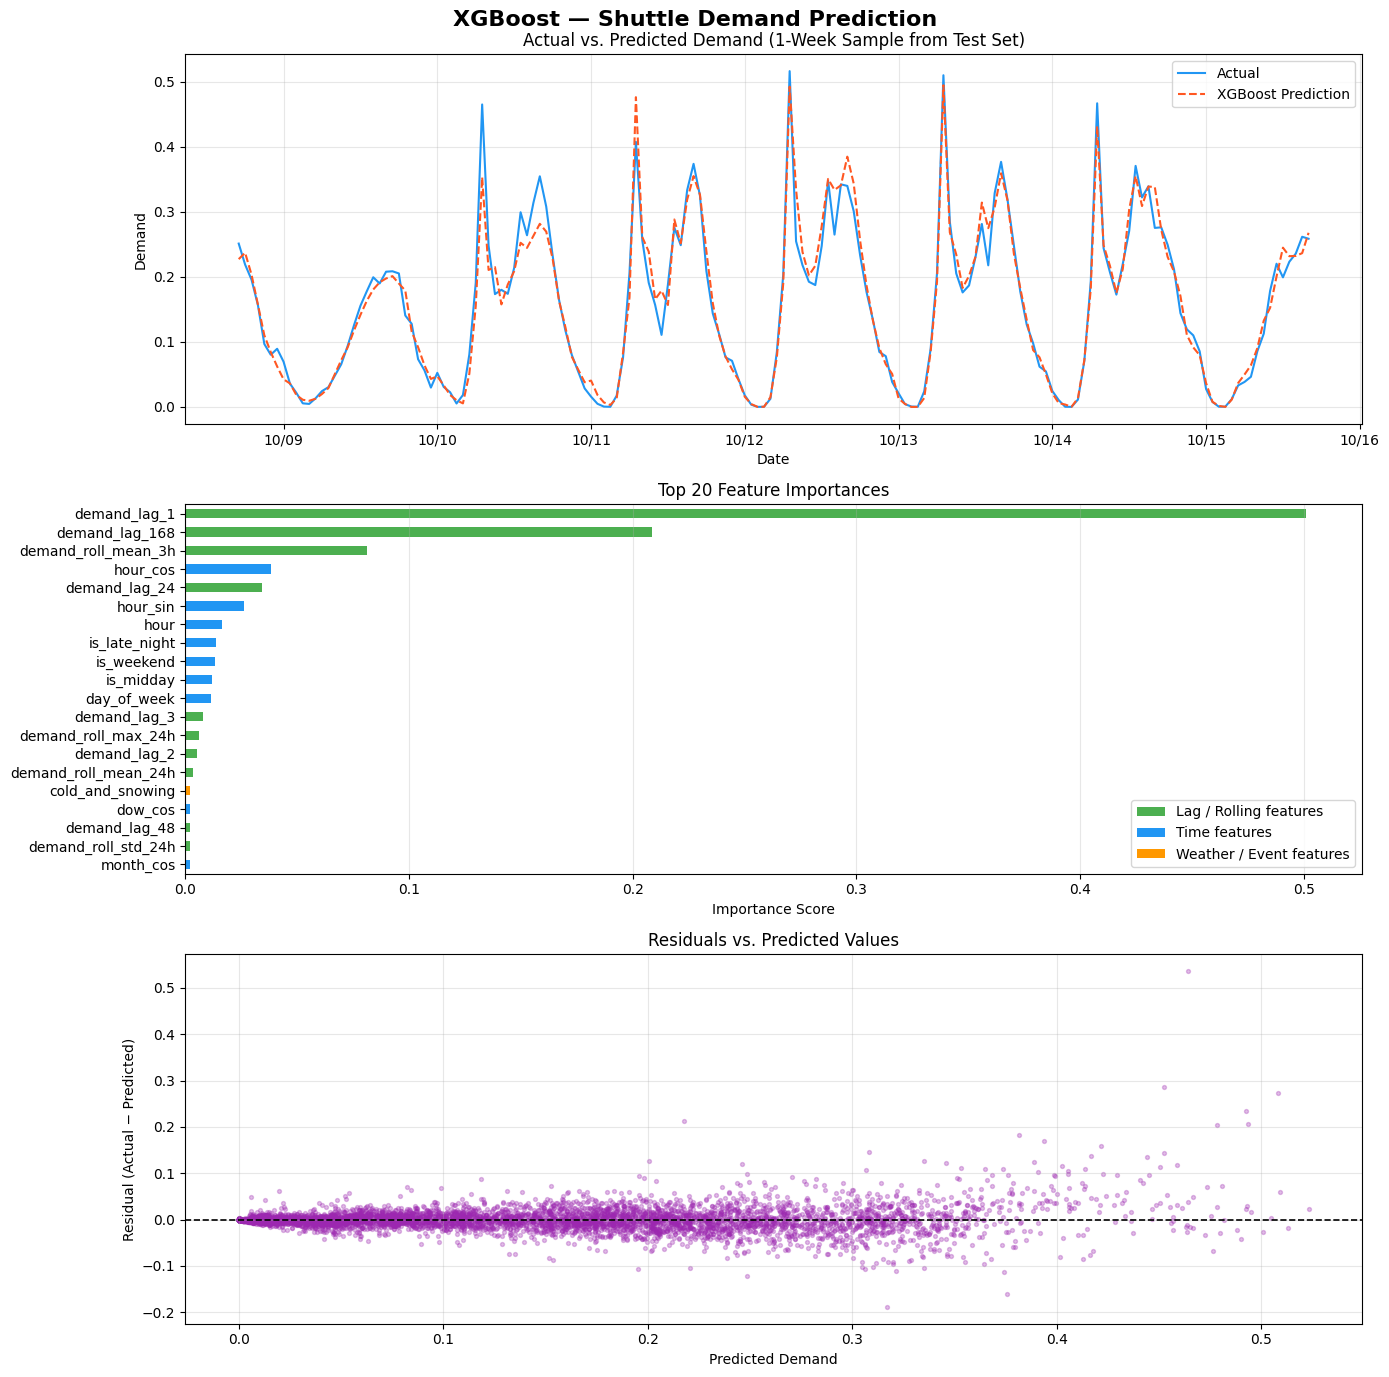


Plot saved → xgboost_results.png


In [51]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
fig.suptitle("XGBoost — Shuttle Demand Prediction", fontsize=16, fontweight="bold")

# Plot 1: Actual vs Predicted (1-week sample)
ax = axes[0]
sample_dates = df_feat["datetime"].iloc[split_idx : split_idx + 168]
ax.plot(sample_dates, y_test.values[:168], label="Actual",
        color="#2196F3", linewidth=1.5)
ax.plot(sample_dates, y_pred[:168],        label="XGBoost Prediction",
        color="#FF5722", linewidth=1.5, linestyle="--")
ax.set_title("Actual vs. Predicted Demand (1-Week Sample from Test Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Demand")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.grid(alpha=0.3)

# Plot 2: Top 20 Feature Importances
ax = axes[1]
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
top20 = importance.nlargest(20)

def get_color(f):
    if "demand" in f: return "#4CAF50"
    if any(t in f for t in ["hour","dow","month","week","day","peak","midday","night"]):
        return "#2196F3"
    return "#FF9800"

colors = [get_color(f) for f in top20.sort_values().index]
top20.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.set_title("Top 20 Feature Importances")
ax.set_xlabel("Importance Score")
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#4CAF50", label="Lag / Rolling features"),
    Patch(facecolor="#2196F3", label="Time features"),
    Patch(facecolor="#FF9800", label="Weather / Event features"),
], loc="lower right")

# Plot 3: Residuals
ax = axes[2]
residuals = y_test.values - y_pred
ax.scatter(y_pred, residuals, alpha=0.3, s=8, color="#9C27B0")
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_title("Residuals vs. Predicted Values")
ax.set_xlabel("Predicted Demand")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('../../Graphs', exist_ok=True)
plt.savefig("../../Graphs/xgboost_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → xgboost_results.png")


In [52]:
print("\n=== Weather Impact on Demand (Test Set) ===")
test_df = df_feat.iloc[split_idx:].copy()
test_df["predicted"] = y_pred

conditions = {
    "Snowing"        : test_df["is_snowing"]  == 1,
    "Raining"        : test_df["is_raining"]  == 1,
    "Below Freezing" : test_df["feelslike"]   <  32,
    "Event Day"      : test_df["event"]       == 1,
    "Clear / Normal" : test_df["bad_weather"] == 0,
}

for label, mask in conditions.items():
    subset = test_df[mask]
    if len(subset) > 0:
        print(f"  {label:<20}: "
              f"Actual = {subset['demand'].mean():>8,.0f} | "
              f"Predicted = {subset['predicted'].mean():>8,.0f} | "
              f"n = {len(subset)}")



=== Weather Impact on Demand (Test Set) ===
  Below Freezing      : Actual =        0 | Predicted =        0 | n = 5650
  Event Day           : Actual =        0 | Predicted =        0 | n = 580
  Clear / Normal      : Actual =        0 | Predicted =        0 | n = 5650
